In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# maf=1e-3
# n = !wc -l $eur_samples_path
# n_eur = int(n[0].split(' ')[0])
# mac = maf*(2*n_eur)

mac = 20

config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#00838F""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#26C6DA""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#80CBC4""","""PromoterAI abs""",-1


In [3]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251130.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251130_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
min_range = -100
max_range = +0

variant_class = "missense"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

abs_phenotypes = False
extreme_pheno_dir = 'Bottom'

anno_wide = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
    # .filter(pl.col('gene_name').is_in(['LDLR', 'APOB']))
)

anno_wide

cadd_raw,gene_name,esmscoremissense,id,absplice_dna_max,score_pai3d,gpn_star_llr_calibrated_mean,absplice2_max,gene_length,am_pathogenicity,abexp_abs_max,promoterai,promoterai_abs,region,strand,verphylop,loftee_hc,delta_score,pangolin_score,dist_to_tss,tss
f32,str,f32,str,f32,f32,f32,f32,i64,f32,f32,f32,f32,str,str,f32,i8,f32,f32,i64,i64
5.289581,"""SEC16B""",-7.779,"""chr1:177946510:G:A""",0.011,0.793948,-7.272596,0.002355,60349,0.748,0.140443,0.0,0.0,"""ENSG00000120341""","""-1""",9.96,0,0.03,0.04,37793,177984303
2.316195,"""SEC16B""",-2.685,"""chr1:177960806:T:A""",0.003,0.49196,-5.665048,0.000854,60349,0.2993,0.112486,0.0,0.0,"""ENSG00000120341""","""-1""",-0.001,0,0.0,0.01,23497,177984303
5.857862,"""SEC16B""",-7.18,"""chr1:177942016:G:A""",0.005,0.795879,-7.034506,0.000982,60349,0.2027,0.126506,0.0,0.0,"""ENSG00000120341""","""-1""",10.03,0,0.12,0.03,42287,177984303
1.301943,"""TSC1""",0.0,"""chr9:132925608:A:G""",0.004,0.0,-4.20307,0.001386,55528,0.0,0.093468,0.0,0.0,"""ENSG00000165699""","""-1""",1.1,0,0.06,0.09,21266,132946874
-0.167611,"""SEC16B""",0.0,"""chr1:177937377:C:T""",0.0,0.0,0.110868,0.000034,60349,0.0,0.005501,0.0,0.0,"""ENSG00000120341""","""-1""",-2.216,0,0.03,0.03,46926,177984303
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3.637395,"""RAD51""",-8.502,"""chr15:40698837:C:T""",0.003,0.797106,-8.260452,0.002202,37568,0.2858,0.059222,0.0,0.0,"""ENSG00000051180""","""1""",0.16,0,0.0,0.02,4064,40694773
4.087614,"""TET1""",-3.645,"""chr10:68572606:C:G""",0.001,0.576393,-5.042427,0.000034,134152,0.2283,0.015385,0.0,0.0,"""ENSG00000138336""","""1""",4.533,0,0.0,0.02,12270,68560336
4.322935,"""RAD51""",-4.857,"""chr15:40728740:A:C""",0.003,0.827792,-11.46476,0.000348,37568,0.8616,0.070655,0.0,0.0,"""ENSG00000051180""","""1""",8.618,0,0.0,0.0,33967,40694773


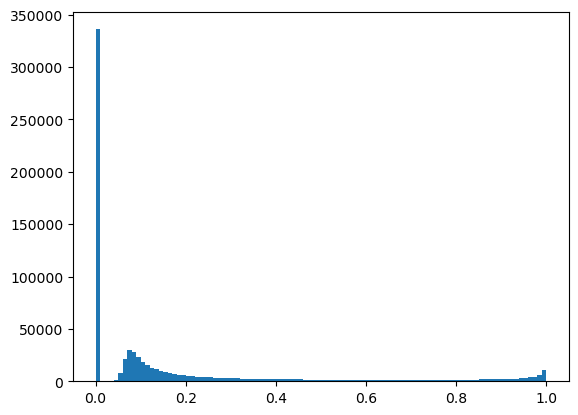

In [4]:
plt.hist(anno_wide['am_pathogenicity'].drop_nulls(), bins=100)
plt.show()

In [5]:
selected_annos = anno_config_df.filter(
    (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    # pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'

    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
)['annotation'].to_list()

melted_anno = (
    anno_wide

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null())
    )

    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]).cast(pl.Float32),
        anno_score_count = pl.len().over(["region", "annotation"]).cast(pl.Int32)
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count').round(4).cast(pl.Float32)
    )
    .drop(['anno_score_count', 'annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile
str,str,str,f32,str,i8,f32,f32
"""chr1:177946510:G:A""","""ENSG00000120341""","""am_pathogenicity""",0.748,"""missense""",1,1355.0,0.967166
"""chr1:177960806:T:A""","""ENSG00000120341""","""am_pathogenicity""",0.2993,"""missense""",1,1266.0,0.90364
"""chr1:177942016:G:A""","""ENSG00000120341""","""am_pathogenicity""",0.2027,"""missense""",1,1222.0,0.872234
"""chr9:132925608:A:G""","""ENSG00000165699""","""am_pathogenicity""",0.0,"""missense""",1,241.5,0.19351
"""chr1:177937377:C:T""","""ENSG00000120341""","""am_pathogenicity""",0.0,"""missense""",1,295.5,0.210921
…,…,…,…,…,…,…,…
"""chr15:40698837:C:T""","""ENSG00000051180""","""absplice2_max""",0.002202,"""splicing""",1,207.0,0.61976
"""chr10:68572606:C:G""","""ENSG00000138336""","""absplice2_max""",0.000034,"""splicing""",1,1539.0,0.752199
"""chr15:40728740:A:C""","""ENSG00000051180""","""absplice2_max""",0.000348,"""splicing""",1,60.0,0.179641


In [6]:
ptile_counts_df = (
    melted_anno
    .group_by(['annotation', 'annotation_score_dircor_ptile'])
    .agg(
        n_vars_at_ptile = pl.len()
    )
    .sort('annotation_score_dircor_ptile', descending=True)
    .with_columns(
        n_vars_above_ptile = pl.col('n_vars_at_ptile').cum_sum().over('annotation')
    )
)

melted_anno = melted_anno.join(ptile_counts_df, on=['annotation', 'annotation_score_dircor_ptile'], how='inner')
melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile,n_vars_at_ptile,n_vars_above_ptile
str,str,str,f32,str,i8,f32,f32,u64,u64
"""chr1:177946510:G:A""","""ENSG00000120341""","""am_pathogenicity""",0.748,"""missense""",1,1355.0,0.967166,1,23030
"""chr1:177960806:T:A""","""ENSG00000120341""","""am_pathogenicity""",0.2993,"""missense""",1,1266.0,0.90364,4,66686
"""chr1:177942016:G:A""","""ENSG00000120341""","""am_pathogenicity""",0.2027,"""missense""",1,1222.0,0.872234,1,88209
"""chr9:132925608:A:G""","""ENSG00000165699""","""am_pathogenicity""",0.0,"""missense""",1,241.5,0.19351,482,673882
"""chr1:177937377:C:T""","""ENSG00000120341""","""am_pathogenicity""",0.0,"""missense""",1,295.5,0.210921,590,588069
…,…,…,…,…,…,…,…,…,…
"""chr15:40698837:C:T""","""ENSG00000051180""","""absplice2_max""",0.002202,"""splicing""",1,207.0,0.61976,8,262975
"""chr10:68572606:C:G""","""ENSG00000138336""","""absplice2_max""",0.000034,"""splicing""",1,1539.0,0.752199,163,173321
"""chr15:40728740:A:C""","""ENSG00000051180""","""absplice2_max""",0.000348,"""splicing""",1,60.0,0.179641,16,618388


In [7]:
ct_df = melted_anno.group_by('annotation').agg(
    n_vars = pl.len(),
    max_ptile = pl.col('annotation_score_dircor_ptile').max(),
).sort('n_vars', descending=True)

# ct_df['max_ptile'].min()

assert ct_df['max_ptile'].min() == 1.0
ct_df

annotation,n_vars,max_ptile
str,u64,f32
"""gpn_star_llr_calibrated_mean""",733918,1.0
"""verphylop""",733918,1.0
"""am_pathogenicity""",733918,1.0
"""cadd_raw""",733918,1.0
"""pangolin_score""",733918,1.0
"""absplice_dna_max""",733918,1.0
"""absplice2_max""",733918,1.0
"""esmscoremissense""",733918,1.0
"""score_pai3d""",733918,1.0


## Odds ratio computation

In [8]:
n_steps = 101
min_rank_cutoff = 100
max_rank_cutoff = 1_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno_wide.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
100
109
119
130
142
…
514069
561924
614235


In [9]:
# Read Olink RVAT significant
olnk_subset = pl.read_csv('/home/dnanexus/data_dir/olink/olink_genebass1e6_371genes.tsv', separator='\t')
olnk_rvat_genes = (
    pl.read_csv('/home/dnanexus/data_dir/olink/olink_rvat_fdr.tsv', separator='\t')
    .filter(pl.col('is_plof_significant_fdr')==True)
    .filter(pl.col('n_pos')>=10)
    .filter(pl.col('gene').is_in(olnk_subset['region']))['gene'].to_list()
)
olnk_rvat_genes = [g+'_olink' for g in olnk_rvat_genes]


# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

# Merge phenotype data and annotation data
gp_corr_df = (
    olink_appv
    .filter(
        (pl.col('phenotype').is_in(olnk_rvat_genes)) &
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(pl.col('mean_pheno_value'))
    )
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('phenotype')
    )
    .with_columns(
        mean_pheno_value_rank=pl.col('mean_pheno_value')
            .rank(method="average")
            .cast(pl.Float32)
    )
    .with_columns(
        mean_pheno_value_ptile=(
            pl.col('mean_pheno_value_rank') / pl.len()
        ).cast(pl.Float32)
    )
    .with_columns(
        mean_pheno_value_ptile = pl.when(extreme_pheno_dir.lower() == 'bottom')
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
    .rename({
        'phenotype': 'olink_prot',
    })
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_corr_df
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "olink_prot", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)

or_df

/tmp/ipykernel_310478/2380528114.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Executing with odds ratios...


annotation,region,olink_prot,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,i64,u64,u64,u64,u64,f64
"""verphylop""","""ENSG00000120053""","""ENSG00000120053_olink""",733918,5,86,0,0,NaN
"""absplice_dna_max""","""ENSG00000171105""","""ENSG00000171105_olink""",733918,0,309,0,0,NaN
"""am_pathogenicity""","""ENSG00000090339""","""ENSG00000090339_olink""",733918,1,147,0,0,NaN
"""absplice_dna_max""","""ENSG00000174827""","""ENSG00000174827_olink""",733918,0,108,0,0,NaN
"""score_pai3d""","""ENSG00000166126""","""ENSG00000166126_olink""",733918,0,167,0,0,NaN
…,…,…,…,…,…,…,…,…
"""absplice2_max""","""ENSG00000108821""","""ENSG00000108821_olink""",100,0,0,2,372,NaN
"""gpn_star_llr_calibrated_mean""","""ENSG00000167601""","""ENSG00000167601_olink""",100,0,0,13,251,NaN
"""pangolin_score""","""ENSG00000105472""","""ENSG00000105472_olink""",100,0,0,1,91,NaN


## Plotting

In [10]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        # log_rank_cutoff_inv = (np.log10(min_rank_cutoff) + np.log10(max_rank_cutoff)) - pl.col('log_rank_cutoff'),
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""gpn_star_llr_calibrated_mean""",3.391464,2463,-3.391464,25,0.0,9.048108,4.392327,17.657069,0.439146,"""#942c80""","""GPN-Star""","""conservation"""
"""gpn_star_llr_calibrated_mean""",3.430236,2693,-3.430236,26,0.0,7.543052,3.809479,15.009631,0.076474,"""#942c80""","""GPN-Star""","""conservation"""
"""delta_score""",3.546172,3517,-3.546172,37,0.0,18.578078,9.233835,36.676395,0.479761,"""#8BC34A""","""SpliceAI""","""splicing"""
"""pangolin_score""",3.584896,3845,-3.584896,43,0.0,10.508181,4.107814,18.559495,2.456866,"""#2E7D32""","""Pangolin""","""splicing"""
"""delta_score""",3.584896,3845,-3.584896,37,0.0,21.084084,9.501508,39.707039,2.461129,"""#8BC34A""","""SpliceAI""","""splicing"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""absplice2_max""",5.826991,671415,-5.826991,16,0.269664,0.654718,0.264079,1.172314,0.137123,"""#26C6DA""","""AbSplice2 (max)""","""splicing"""
"""score_pai3d""",5.826991,671415,-5.826991,13,0.557377,0.835996,0.209704,1.247015,0.424976,"""#D84315""","""PrimateAI-3D""","""missense"""
"""verphylop""",5.826991,671415,-5.826991,7,0.311419,0.487255,0.169878,0.820216,0.154294,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""


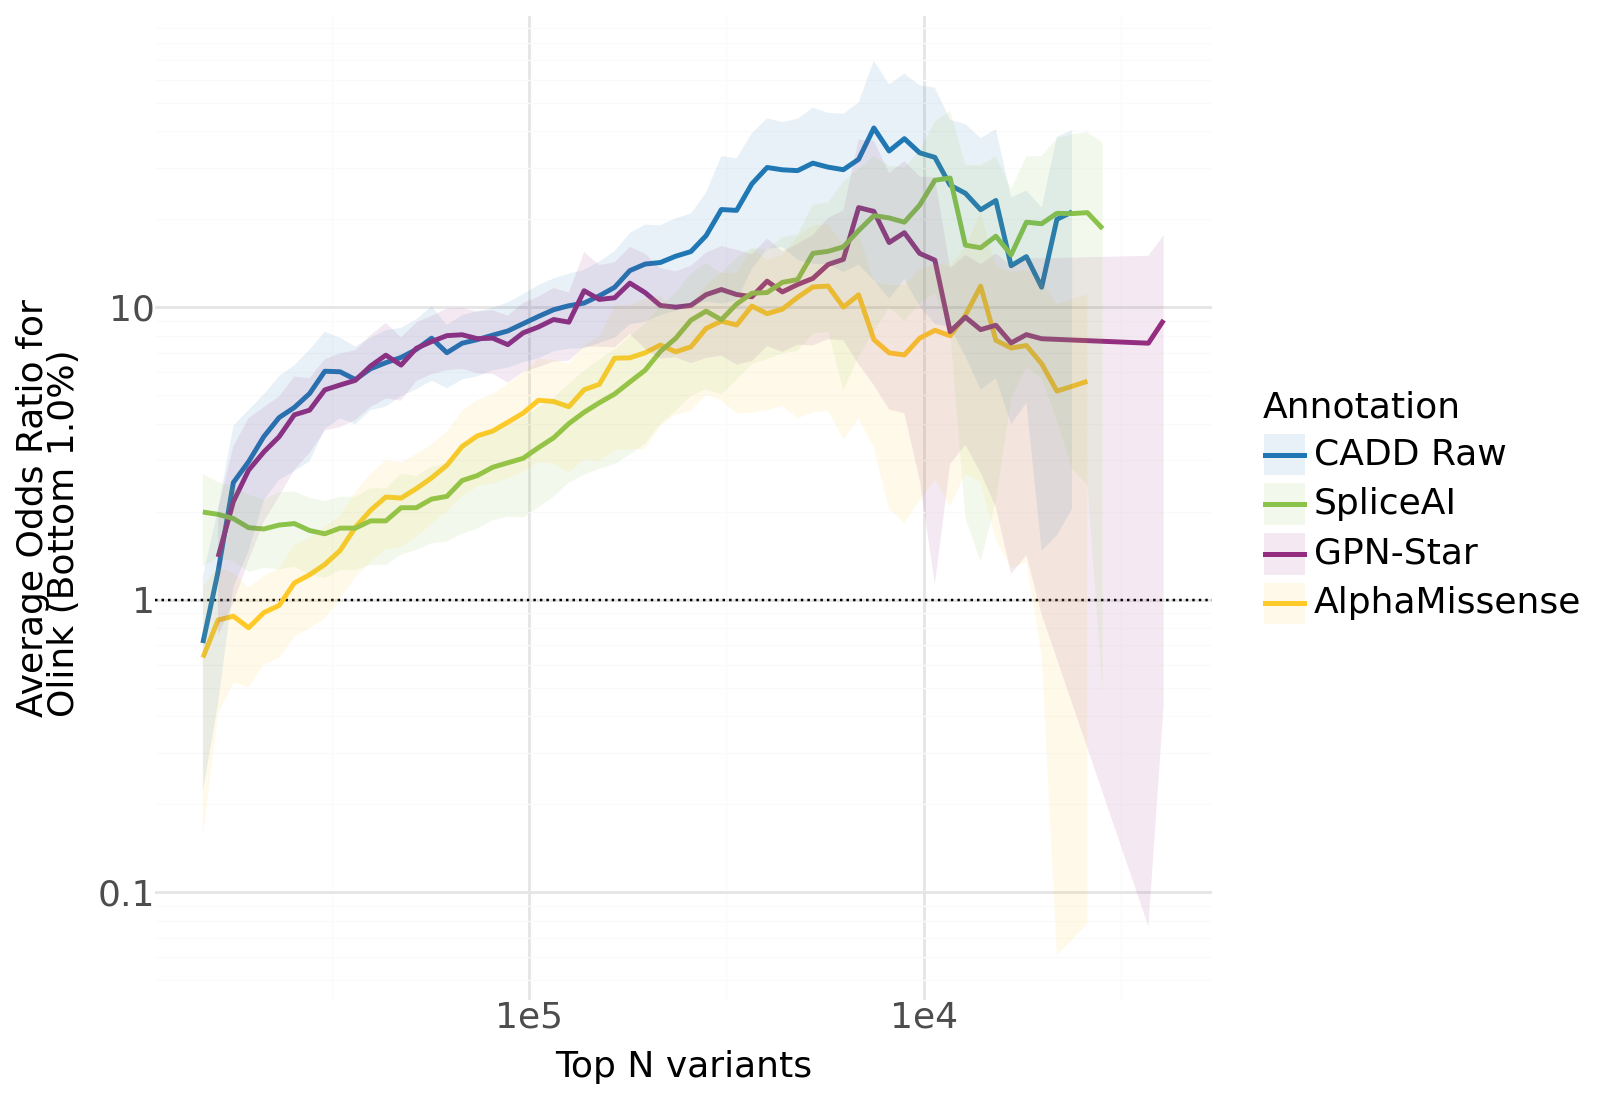

In [ ]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') <= -3.5) &
        (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'delta_score']))
        # (pl.col('category').is_in(['missense', 'genetic_diversity']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

# Determine legend order based on final average odds ratio
legend_order = (
    plt_df.sort("log_rank_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        y=f"Average Odds Ratio for\nOlink ({extreme_pheno_dir} {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

In [ ]:
plt_df.head()

annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""gpn_star_llr_calibrated_mean""",3.391464,2463,-3.391464,25,0.0,9.048108,4.392327,17.657069,0.439146,"""#942c80""","""GPN-Star""","""conservation"""
"""gpn_star_llr_calibrated_mean""",3.430236,2693,-3.430236,26,0.0,7.543052,3.809479,15.009631,0.076474,"""#942c80""","""GPN-Star""","""conservation"""
"""delta_score""",3.546172,3517,-3.546172,37,0.0,18.578078,9.233835,36.676395,0.479761,"""#8BC34A""","""SpliceAI""","""splicing"""
"""delta_score""",3.584896,3845,-3.584896,37,0.0,21.084084,9.501508,39.707039,2.461129,"""#8BC34A""","""SpliceAI""","""splicing"""
"""am_pathogenicity""",3.584896,3845,-3.584896,50,0.0,5.588274,2.811361,11.098541,0.078007,"""#FFCA28""","""AlphaMissense""","""missense"""
